In [ ]:
!pip install torch torchvision torchaudio --q
!pip install torch-geometric --q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.8 MB/s eta 0:00:00


In [ ]:
import networkx as nx
import numpy as np

G = nx.Graph()
num_nodes = 60
num_classes = 3

labels = np.random.randint(0, num_classes, num_nodes)

for i in range(num_nodes):
    label = labels[i]

    feature = np.random.rand(3) + label * 0.3

    G.add_node(i, feature=feature, label=label)

for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        if labels[i] == labels[j]:
            prob = 0.3
        else:
            prob = 0.1

        if np.random.rand() < prob:
            G.add_edge(i, j)

In [ ]:
import torch
from torch_geometric.data import Data

x = torch.tensor([G.nodes[i]['feature'] for i in G.nodes()], dtype=torch.float)
y = torch.tensor([G.nodes[i]['label'] for i in G.nodes()], dtype=torch.long)

edge_index = torch.tensor(list(G.edges())).t().contiguous()
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

data = Data(x=x, edge_index=edge_index, y=y)

In [ ]:
num_nodes = data.num_nodes

indices = torch.randperm(num_nodes)

train_size = int(0.8 * num_nodes)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
test_mask[indices[train_size:]] = True

data.train_mask = train_mask
data.test_mask = test_mask


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(3, 16)
        self.conv2 = GCNConv(16, 3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GCN().to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

In [ ]:
def train():
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    return loss.item()

In [ ]:
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())

    return acc

In [ ]:
train_losses = []
test_acc_list = []

for epoch in range(1, 101):
    loss = train()
    acc = test()

    train_losses.append(loss)
    test_acc_list.append(acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Test Acc: {acc:.4f}")

Epoch 10, Loss: 1.1090, Test Acc: 0.1667
Epoch 20, Loss: 1.0794, Test Acc: 0.5000
Epoch 30, Loss: 1.0641, Test Acc: 0.5000
Epoch 40, Loss: 1.0550, Test Acc: 0.5000
Epoch 50, Loss: 1.0533, Test Acc: 0.5000
Epoch 60, Loss: 1.0109, Test Acc: 0.5833
Epoch 70, Loss: 1.0098, Test Acc: 0.5833
Epoch 80, Loss: 0.9606, Test Acc: 0.5833
Epoch 90, Loss: 0.9513, Test Acc: 0.5833
Epoch 100, Loss: 0.9015, Test Acc: 0.5833


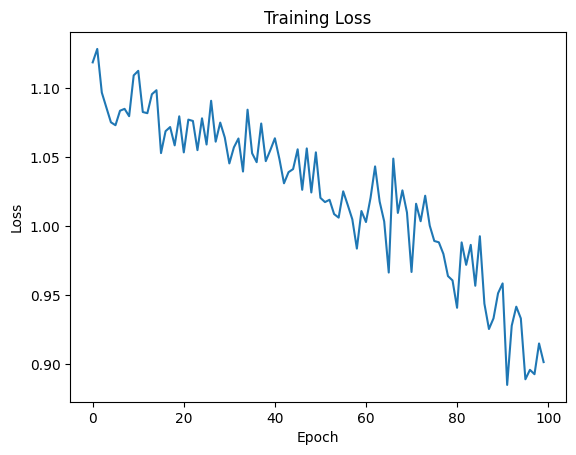

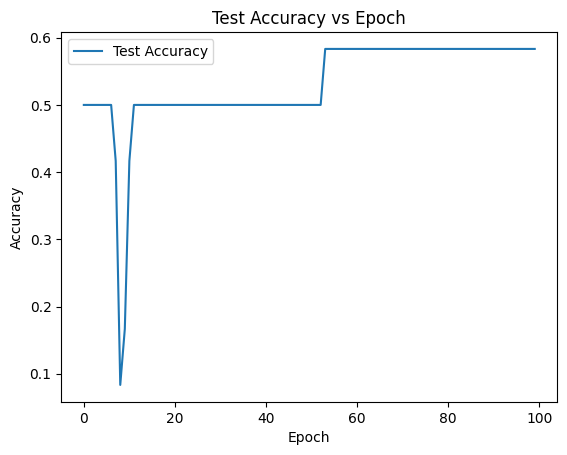

In [ ]:
import matplotlib.pyplot as plt

# Loss graph
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Accuracy graph
plt.figure()
plt.plot(test_acc_list, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy vs Epoch")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
out = model(data.x, data.edge_index)
pred = out.argmax(dim=1)

y_true = data.y[data.test_mask].cpu()
y_pred = pred[data.test_mask].cpu()

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         6
           1       0.00      0.00      0.00         5
           2       0.33      1.00      0.50         1

    accuracy                           0.58        12
   macro avg       0.33      0.67      0.43        12
weighted avg       0.36      0.58      0.44        12

Confusion Matrix:

[[6 0 0]
 [3 0 2]
 [0 0 1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
